In [81]:
import numpy as np 
import polars as pl 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [239]:
df = pl.scan_csv(r'C:\Users\erics\courses\gradml1\crypto_pred_market\data_gather\final_data\final_data.csv').collect()
df = df.filter(pl.col('time_to_close').is_between(400,600))

In [240]:
df.head()

curr_time,open_time,close_time,prev_time,time_to_close,last_price_dollars,yes_mid_dollars,yes_spread_dollars,distance_from_strike,yes_mid_change_1s,yes_mid_change_5s,yes_mid_change_std_30s,yes_mid_change_std_60s,yes_spread_mean_30s,next_price_dollars_lead1,outcome,ETH_last_price_dollars,ETH_yes_mid_dollars,ETH_yes_spread_dollars,ETH_distance_from_strike,ETH_yes_mid_change_1s,ETH_yes_mid_change_5s,ETH_yes_mid_change_std_30s,ETH_yes_mid_change_std_60s,ETH_yes_spread_mean_30s,XRP_last_price_dollars,XRP_yes_mid_dollars,XRP_yes_spread_dollars,XRP_distance_from_strike,XRP_yes_mid_change_1s,XRP_yes_mid_change_5s,XRP_yes_mid_change_std_30s,XRP_yes_mid_change_std_60s,XRP_yes_spread_mean_30s,SOL_last_price_dollars,SOL_yes_mid_dollars,SOL_yes_spread_dollars,SOL_distance_from_strike,SOL_yes_mid_change_1s,SOL_yes_mid_change_5s,SOL_yes_mid_change_std_30s,SOL_yes_mid_change_std_60s,SOL_yes_spread_mean_30s,btc_spot_price,btc_spot_size_1s,btc_spot_signed_size_1s,btc_spot_return_1s,btc_spot_return_5s,btc_spot_return_15s,btc_spot_return_60s,btc_spot_return_vol_30s,btc_spot_return_vol_5m,btc_spot_signed_flow_mean_30s,btc_spot_size_mean_30s
str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2026-03-21T10:49:59.317382+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:49:58.316029+000…",600,0.37,0.365,0.01,-20.41,0.0,0.0,0.007303,0.006507,0.01,0.37,1,0.11,0.105,0.01,-2.02,0.0,0.0,0.002739,0.002052,0.012333,0.18,0.195,0.01,-0.0011,0.01,0.01,0.001826,0.006561,0.029333,0.22,0.205,0.03,-0.0788,0.0,0.0,0.001826,0.003456,0.02,70560.74,0.001313,-0.001265,0.0,1.4172e-7,0.0,0.000055,0.000012,0.0,0.000976,0.002451
"""2026-03-21T10:50:00.320060+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:49:59.317382+000…",599,0.37,0.365,0.01,-20.41,0.0,0.0,0.007303,0.006507,0.01,0.37,1,0.11,0.105,0.01,-2.03,0.0,0.0,0.002739,0.002052,0.012,0.18,0.195,0.01,-0.0011,0.0,0.01,0.001826,0.004103,0.028667,0.22,0.205,0.03,-0.0788,0.0,0.0,0.001826,0.003456,0.020667,70560.74,0.000188,-0.000188,0.0,0.0,0.0,0.000055,0.000012,0.0,0.000973,0.002454
"""2026-03-21T10:50:01.342921+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:50:00.320060+000…",598,0.37,0.365,0.01,-20.41,0.0,0.0,0.007303,0.006507,0.01,0.37,1,0.11,0.105,0.01,-2.03,0.0,0.0,0.002739,0.002052,0.011667,0.18,0.195,0.01,-0.0011,0.0,0.01,0.001826,0.004103,0.028,0.22,0.205,0.03,-0.0788,0.0,0.0,0.001826,0.003456,0.021333,70560.74,4.4000e-7,-4.4000e-7,0.0,0.0,0.0,0.000055,0.000012,0.0,0.000987,0.00244
"""2026-03-21T10:50:02.343903+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:50:01.342921+000…",597,0.37,0.365,0.01,-20.41,0.0,0.0,0.007303,0.006507,0.01,0.37,1,0.11,0.105,0.01,-2.02,0.0,0.0,0.002739,0.002052,0.011333,0.18,0.195,0.01,-0.0011,0.0,0.01,0.001826,0.004103,0.027333,0.22,0.205,0.03,-0.0788,0.0,0.0,0.001826,0.003456,0.022,70560.74,0.144044,-0.144044,0.0,0.0,0.0,0.000055,0.000011,0.0,-0.003927,0.00712
"""2026-03-21T10:50:03.345577+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:50:02.343903+000…",596,0.37,0.365,0.01,-18.76,0.0,0.0,0.007303,0.006507,0.01,0.37,1,0.11,0.105,0.01,-2.02,0.0,0.0,0.002739,0.002052,0.011,0.18,0.195,0.01,-0.0011,0.0,0.01,0.001826,0.004103,0.026667,0.22,0.205,0.03,-0.0788,0.0,0.0,0.001826,0.003456,0.022667,70562.39,4.4000e-7,-4.4000e-7,0.000023,0.000023,0.000023,0.000078,0.000012,0.0,-0.003851,0.007044


In [241]:
def _to_datetime(table: pl.DataFrame, cols: list) -> pl.DataFrame:
        for col in cols: 
            table = table.with_columns(
                pl.col(col)
                .str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%#z", strict=False)
                .alias(col)
            )
        return table

df = _to_datetime(df, cols = ['curr_time', 'open_time', 'close_time', 'prev_time'])


In [242]:
event_col_ids = ['open_time', 'close_time']
event_ids = (df.select(event_col_ids).unique().sort('open_time'))
n = 0.7

X_train_ids = event_ids[:round(n*len(event_ids))]
X_test_ids = event_ids[round(n*len(event_ids)):]

y_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').select('outcome')
X_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1')

y_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').select('outcome')
X_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1')



In [243]:
from sklearn.model_selection import GroupShuffleSplit

groups = df['open_time'].cast(str) + '_' + df['close_time'].cast(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

drop_cols = ['curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1']

X_train = df[train_idx].drop(drop_cols)
y_train = df[train_idx].select('outcome')
X_test = df[test_idx].drop(drop_cols)
y_test = df[test_idx].select('outcome')

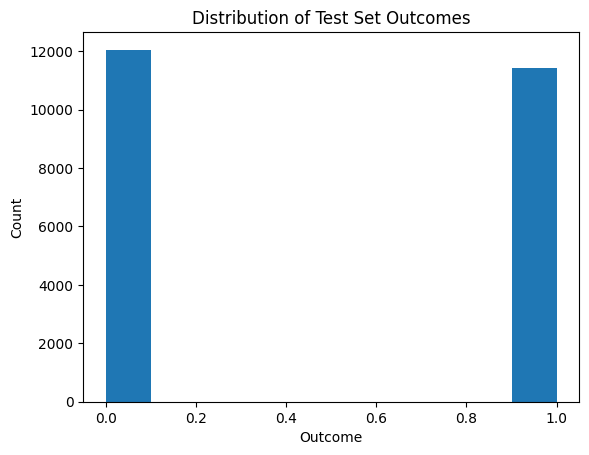

In [244]:
import matplotlib.pyplot as plt 
plt.hist(y_test)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

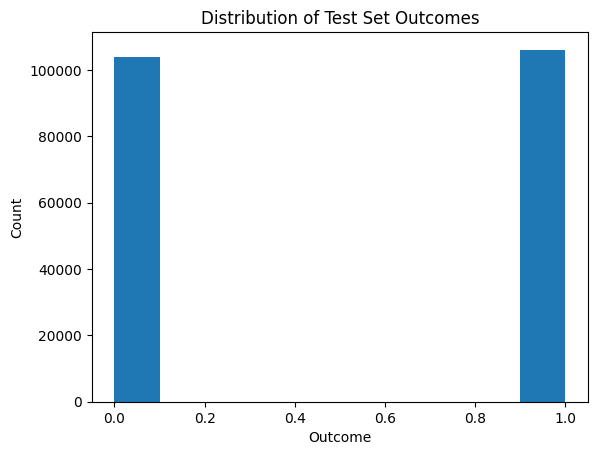

In [245]:
import matplotlib.pyplot as plt 
plt.hist(y_train)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

In [246]:
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [247]:
log_reg.score(X_test.to_numpy(), y_test.to_numpy().ravel())
y_pred = log_reg.predict(X_test.to_numpy())
print("Accuracy:", accuracy_score(y_test.to_numpy().ravel(), y_pred))
print(confusion_matrix(y_test.to_numpy().ravel(), y_pred))
print(classification_report(y_test.to_numpy().ravel(), y_pred))

Accuracy: 0.7574415534642082
[[8810 3239]
 [2457 8977]]
              precision    recall  f1-score   support

           0       0.78      0.73      0.76     12049
           1       0.73      0.79      0.76     11434

    accuracy                           0.76     23483
   macro avg       0.76      0.76      0.76     23483
weighted avg       0.76      0.76      0.76     23483



In [238]:
- we need to bucket accordingly. predictions made at the start is definitelyl going to be wrong 
- predictions made closer to the time of expiration? how does this perform?? 
- lets also look at the difference between the kalshi mid price and our predicted probabilities. 

SyntaxError: invalid syntax (1371051538.py, line 1)